## Seting up runpod environment

In [ ]:
!python -c "import monai" || pip install -q "monai-weekly[nibabel]"
!python -c "import matplotlib" || pip install -q matplotlib
%matplotlib inline

Traceback (most recent call last):
  File "<string>", line 1, in <module>
ModuleNotFoundError: No module named 'monai'

[notice] A new release of pip is available: 24.2 -> 26.0
[notice] To update, run: python -m pip install --upgrade pip
Traceback (most recent call last):
  File "<string>", line 1, in <module>
ModuleNotFoundError: No module named 'matplotlib'

[notice] A new release of pip is available: 24.2 -> 26.0
[notice] To update, run: python -m pip install --upgrade pip


In [ ]:
!pip install gdown

In [ ]:
!pip install tensorboard

In [ ]:
## Logging

import logging
import time
from datetime import datetime
import traceback

now = datetime.now()

# Example 1: Standard YYYY-MM-DD HH:MM:SS format
formatted_string = now.strftime("%Y-%m-%d %H:%M:%S")

logging.basicConfig(
    filename=f'training_{formatted_string}.log',
    filemode='a',
    format='%(message)s',
    level=logging.INFO
)

def log_print(msg, level="INFO", timestamp=True):

    parts = []

    if timestamp:
        parts.append(time.strftime("%Y-%m-%d %H:%M:%S"))

    if level is not None:
        parts.append(level)

    # final formatted message
    prefix = "".join(f"[{p}] " for p in parts)
    formatted_msg = f"{prefix}{msg}"

    # console output (unchanged requirement)
    print(msg)

    # file logging
    if level == "ERROR":
        logging.error(formatted_msg)
    elif level == "WARNING":
        logging.warning(formatted_msg)
    else:
        logging.info(formatted_msg)

## Downloading the dataset from google drive to runpod

In [ ]:
!gdown https://drive.google.com/uc?id=1ACZxt7L7ed8lR_EwIcUQgs60744uoBMw

Downloading...
From: https://drive.google.com/uc?id=1ACZxt7L7ed8lR_EwIcUQgs60744uoBMw
To: /workspace/brats2023_5fold.json
100%|██████████████████████████████████████| 1.73M/1.73M [00:00<00:00, 10.7MB/s]


In [ ]:
import os
os.makedirs("/runpod_nvme", exist_ok=True)

In [ ]:
!gdown "https://drive.google.com/uc?id=1vfA_jCq9Wa1qxg065I4t5Xu0k6rfQNoA" -O /runpod_nvme/brats_archive.zip

Downloading...
From (original): https://drive.google.com/uc?id=1vfA_jCq9Wa1qxg065I4t5Xu0k6rfQNoA
From (redirected): https://drive.google.com/uc?id=1vfA_jCq9Wa1qxg065I4t5Xu0k6rfQNoA&confirm=t&uuid=adcf2cda-5ef4-4904-b936-b4feadf6ddbb
To: /runpod_nvme/brats_archive.zip
100%|██████████████████████████████████████| 16.6G/16.6G [03:29<00:00, 79.4MB/s]


In [ ]:
import shutil
import os
import time
import zipfile


zip_file_path = "/runpod_nvme/brats_archive.zip"
local_extract_path = "/runpod_nvme/dataset/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"

def setup_fast_io():
    # Clean up previous runs if needed
    if os.path.exists(local_extract_path):
        log_print("Local data already exists. Skipping setup.", level="INFO", timestamp=True)
        return

    os.makedirs(local_extract_path, exist_ok=True)

    start = time.time()

    log_print(f"Unzipping data...", level="INFO", timestamp=True)
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(local_extract_path)

    log_print(f"Unzip complete in {time.time() - start:.2f}s", level="INFO", timestamp=True)

    # Cleanup to save space
    os.remove("/runpod_nvme/brats_archive.zip")


In [ ]:
setup_fast_io()

Unzipping data...
Unzip complete in 43.58s


In [ ]:
!du -sh "/runpod_nvme/dataset/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"

17G	/runpod_nvme/dataset/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData


In [ ]:
# !du -sh "/runpod_nvme/persistent_cache"

368G	/runpod_nvme/persistent_cache


## Setup imports

In [ ]:
import os
import json
import shutil
import tempfile
import time

import matplotlib.pyplot as plt
import numpy as np
import nibabel as nib

from monai.losses import DiceLoss
from monai.inferers import sliding_window_inference
from monai import transforms
from monai.transforms import (
    AsDiscrete,
    Activations,
)

from monai.config import print_config
from monai.metrics import DiceMetric
from monai.utils.enums import MetricReduction
from monai.networks.nets import UNet
from monai import data
from monai.data import decollate_batch
from functools import partial

import torch


print_config()

MONAI version: 1.6.dev2604
Numpy version: 1.26.3
Pytorch version: 2.4.1+cu124
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: b49cdf0aebaf542f04bae27de238069898c0eda2
MONAI __file__: /usr/local/lib/python3.11/dist-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 5.3.3
scikit-image version: NOT INSTALLED or UNKNOWN VERSION.
scipy version: NOT INSTALLED or UNKNOWN VERSION.
Pillow version: 10.2.0
Tensorboard version: NOT INSTALLED or UNKNOWN VERSION.
gdown version: 5.2.1
TorchVision version: 0.19.1+cu124
tqdm version: 4.67.2
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 6.0.0
pandas version: NOT INSTALLED or UNKNOWN VERSION.
einops version: NOT INSTALLED or UNKNOWN VERSION.
transformers version: NOT INSTALLED or UNKNOWN VERSION.
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or

In [ ]:
os.cpu_count()

48

## Setup data directory

In [ ]:
directory = "/workspace/monai_data/dual_decoder_UNet"
if directory is not None:
    os.makedirs(directory, exist_ok=True)
root_dir = tempfile.mkdtemp() if directory is None else directory
log_print(f"Model Checkpoint Saving Directory: {root_dir}", level="INFO", timestamp=True)

Model Checkpoint Saving Directory: /workspace/monai_data/dual_decoder_UNet


## Setup average meter, fold reader, checkpoint saver, checkpoint loader

In [ ]:
class AverageMeter(object):
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = np.where(self.count > 0, self.sum / self.count, self.sum)


def datafold_read(datalist, basedir, fold=0, key="training"):
    with open(datalist) as f:
        json_data = json.load(f)

    json_data = json_data[key]

    for d in json_data:
        for k in d:
            if isinstance(d[k], list):
                d[k] = [os.path.join(basedir, iv) for iv in d[k]]
            elif isinstance(d[k], str):
                d[k] = os.path.join(basedir, d[k]) if len(d[k]) > 0 else d[k]

    tr = []
    val = []
    for d in json_data:
        if "fold" in d and d["fold"] == fold:
            val.append(d)
        else:
            tr.append(d)

    return tr, val

def unwrap_model(model):
    """Return the base (uncompiled) model if torch.compile was used."""

    if hasattr(model, "_orig_mod"):
      log_print('Compiled model was detected! Unwrapping.', level="INFO", timestamp=True)
      return model._orig_mod
    else:
      return model

def save_checkpoint(
    model, epoch, optimizer, scheduler, history, best_acc,
    loss_func=None, scaler=None,
    filename="model_last.pt", dir_add=root_dir, is_best=False
):
    # Always unwrap model before saving (handles both compiled and uncompiled)
    base_model = unwrap_model(model)

    state = {
        "epoch": epoch,
        "state_dict": base_model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "history": history,
        "best_acc": best_acc,
    }

    # Save loss function parameters
    if loss_func is not None:
        state["loss_state_dict"] = loss_func.state_dict()
        log_print(f"Saved loss function state (log_vars: {loss_func.log_vars.data})", level="INFO", timestamp=True)
    else:
        log_print("WARNING: loss_func is None - uncertainty weights will NOT be saved!", level="WARNING", timestamp=True)

    # Save GradScaler state for AMP
    if scaler is not None:
        state["scaler"] = scaler.state_dict()
        log_print("Saved GradScaler state for AMP", level="INFO", timestamp=True)

    # Save checkpoint
    filepath_last = os.path.join(dir_add, "model_last.pt")
    torch.save(state, filepath_last)

    if is_best:
        filepath_best = os.path.join(dir_add, "model_best.pt")
        shutil.copyfile(filepath_last, filepath_best)
        log_print(f"Saved new best model at epoch {epoch} with acc {best_acc:.4f}", level="INFO", timestamp=True)
    else:
        log_print(f"Checkpoint saved at epoch {epoch}", level="INFO", timestamp=True)


In [ ]:
def initialize_history():
    """Initialize comprehensive history dictionary for MTL training"""
    return {
        "val_acc_max": 0.0,

        # Validation Accuracy
        "dices_tc": [], "dices_wt": [], "dices_et": [], "dices_avg": [],

        # NEW: Validation Losses
        "val_loss_total": [],
        "val_loss_seg": [],
        "val_loss_geo": [],

        # Training Loss components
        "loss_total": [],
        "loss_seg": [],
        "loss_geo": [],
        "loss_con": [],

        # Uncertainty weights (precision = 1/σ²)
        "weight_seg": [],
        "weight_geo": [],
        "weight_con": [],

        # Learned uncertainty parameters (log variance)
        "log_var_seg": [],
        "log_var_geo": [],
        "log_var_con": [],

        # Derived sigmas (σ = sqrt(exp(log_var)))
        "sigma_seg": [],
        "sigma_geo": [],
        "sigma_con": [],

        # Training epochs
        "trains_epoch": []
    }

In [ ]:
def load_checkpoint(model, optimizer, scheduler, loss_func=None, scaler=None, filename="model_last.pt"):

    if not os.path.isfile(filename):
        log_print(f"No checkpoint found at {filename}", level="WARNING", timestamp=True)
        return None

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    log_print(f"Loading checkpoint from {filename}...", level="INFO", timestamp=True)
    checkpoint = torch.load(filename, map_location=device, weights_only=False)

    # Always unwrap model before loading (handles both compiled and uncompiled)
    base_model = unwrap_model(model)

    # Load model weights
    base_model.load_state_dict(checkpoint["state_dict"])
    log_print("Model weights loaded", level="INFO", timestamp=True)

    # Epoch & best acc
    start_epoch = checkpoint.get("epoch", -1) + 1
    best_acc = checkpoint.get("best_acc", 0.0)

    # Optimizer
    if "optimizer" in checkpoint:
        optimizer.load_state_dict(checkpoint["optimizer"])
        log_print("Optimizer state loaded", level="INFO", timestamp=True)
    else:
        log_print("WARNING: Optimizer state missing - starting fresh", level="WARNING", timestamp=True)

    # Scheduler
    if "scheduler" in checkpoint:
        scheduler.load_state_dict(checkpoint["scheduler"])
        log_print("Scheduler state loaded", level="INFO", timestamp=True)
    else:
        log_print("WARNING: Scheduler state missing - fast-forwarding manually", level="WARNING", timestamp=True)
        for _ in range(start_epoch):
            scheduler.step()

    # Loss function
    if loss_func is not None and "loss_state_dict" in checkpoint:
        loss_func.load_state_dict(checkpoint["loss_state_dict"])
        # log_print(f"Loss function state loaded (log_vars: {loss_func.log_vars.data})", level="INFO", timestamp=True)
    elif loss_func is not None:
        log_print("WARNING: Loss function state missing - uncertainty weights will reset!", level="WARNING", timestamp=True)

    # GradScaler for AMP
    if scaler is not None and "scaler" in checkpoint:
        scaler.load_state_dict(checkpoint["scaler"])
        log_print("GradScaler state loaded", level="INFO", timestamp=True)
    elif scaler is not None:
        log_print("WARNING: GradScaler state missing - AMP scaling will reset", level="WARNING", timestamp=True)

    # History
    history = checkpoint.get("history", initialize_history())
    history["val_acc_max"] = max(history.get("val_acc_max", 0.0), best_acc)

    log_print(f"Resumed from epoch {start_epoch}, best acc {best_acc:.4f}", level="INFO", timestamp=True)
    return start_epoch, best_acc, history

## Setting up Data loader

In [ ]:
from monai.data import (
    CacheDataset,
    Dataset,
    DataLoader,
    LMDBDataset,
    PersistentDataset,
    decollate_batch,
)

In [ ]:
from monai.transforms import MapTransform

class ShiftGeodesicMinusOned(MapTransform):
    """
    Subtract 1.0 AFTER MONAI transforms.
    Final range: [-1, 1] → matches tanh output.
    """
    def __call__(self, data):
        d = dict(data)
        if self.keys[0] in d:
            d[self.keys[0]] = d[self.keys[0]] - 1.0
        return d


In [ ]:
from monai import transforms, data
from monai.data import PersistentDataset
from monai.transforms import CastToTyped
import torch
import os

def get_loader(batch_size, data_dir, json_list, fold, roi, debug=False):
    train_files, val_files = datafold_read(
        datalist=json_list, basedir=data_dir, fold=fold
    )

    if debug:
        log_print("!!! DEBUG MODE ACTIVE: Reducing dataset size !!!", level="WARNING", timestamp=True)
        train_files = train_files[:10]
        val_files = val_files[:2]


    ## Pre transforms. They re deterministic and cached in the persistent storage
    train_pre_transforms = transforms.Compose([
        transforms.LoadImaged(keys=["image", "label", "geodesic_avg"]),
        transforms.EnsureChannelFirstd(keys=["image", "geodesic_avg"]),
        transforms.MapLabelValued(keys=["label"], orig_labels=[3], target_labels=[4]),
        transforms.ConvertToMultiChannelBasedOnBratsClassesd(keys="label"),

        transforms.ScaleIntensityRangePercentilesd(
            keys="image",
            lower=0.5,
            upper=99.5,
            b_min=0.0,
            b_max=1.0,
            clip=True,
            channel_wise=True,
        ),

        transforms.CropForegroundd(
            keys=["image", "label", "geodesic_avg"],
            source_key="image",
            k_divisible=roi,
            allow_smaller=True,
        ),

        # compression (geodesic maps won't be compressed)
        CastToTyped(keys=["geodesic_avg"], dtype=torch.float32),
        CastToTyped(keys=["image"], dtype=torch.float16),
        CastToTyped(keys=["label"], dtype=torch.uint8),
    ])


    ## Random and online transformations
    train_aug_transforms = transforms.Compose([
        CastToTyped(
            keys=["image", "label"], dtype=torch.float32
        ),

        transforms.RandSpatialCropd(
            keys=["image", "label", "geodesic_avg"],
            roi_size=roi,
            random_size=False,
        ),
        transforms.RandFlipd(keys=["image", "label", "geodesic_avg"], prob=0.5, spatial_axis=0),
        transforms.RandFlipd(keys=["image", "label", "geodesic_avg"], prob=0.5, spatial_axis=1),
        transforms.RandFlipd(keys=["image", "label", "geodesic_avg"], prob=0.5, spatial_axis=2),

        transforms.NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
        transforms.RandScaleIntensityd(keys="image", factors=0.1, prob=1.0),
        transforms.RandShiftIntensityd(keys="image", offsets=0.1, prob=1.0),

        ShiftGeodesicMinusOned(keys=["geodesic_avg"]),
    ])

    # Validation tranformations
    val_pre_transforms = transforms.Compose([
        transforms.LoadImaged(keys=["image", "label", "geodesic_avg"]),
        transforms.EnsureChannelFirstd(keys=["image", "geodesic_avg"]),
        transforms.MapLabelValued(keys=["label"], orig_labels=[3], target_labels=[4]),
        transforms.ConvertToMultiChannelBasedOnBratsClassesd(keys="label"),

        transforms.ScaleIntensityRangePercentilesd(
            keys="image",
            lower=0.5,
            upper=99.5,
            b_min=0.0,
            b_max=1.0,
            clip=True,
            channel_wise=True,
        ),
        CastToTyped(keys=["geodesic_avg"], dtype=torch.float32),
        CastToTyped(keys=["image"], dtype=torch.float16),
        CastToTyped(keys=["label"], dtype=torch.uint8),
    ])

    val_post_transforms = transforms.Compose([
        CastToTyped(
            keys=["image", "label"], dtype=torch.float32
        ),
        transforms.NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
        ShiftGeodesicMinusOned(keys=["geodesic_avg"]),
    ])

    # monai persistent dataset objects
    cache_dir = "/runpod_nvme/persistent_cache"
    os.makedirs(cache_dir, exist_ok=True)

    train_ds_pre = PersistentDataset(
        data=train_files,
        transform=train_pre_transforms,
        cache_dir=cache_dir,
    )

    train_ds = data.Dataset(
        data=train_ds_pre,
        transform=train_aug_transforms,
    )

    val_ds_pre = PersistentDataset(
        data=val_files,
        transform=val_pre_transforms,
        cache_dir=cache_dir,
    )

    val_ds = data.Dataset(
        data=val_ds_pre,
        transform=val_post_transforms,
    )

    # data loaders
    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=6,          # 2–4 is ideal
        pin_memory=True,
        prefetch_factor=2,
        persistent_workers=True,
    )

    val_loader = data.DataLoader(
        val_ds,
        batch_size=1,
        shuffle=False,
        num_workers=2,          # lower than train
        pin_memory=True,
        persistent_workers=True,
        prefetch_factor=2,
    )

    return train_loader, val_loader


## Set dataset root directory and hyper-parameters

In [ ]:
# checkpoint = torch.load("/content/drive/MyDrive/brain_tumor_segmentation/monai_data/dual_decoder_UNet_/model_last.pt", weights_only=False, map_location=device)

In [ ]:
# print(checkpoint.keys())

In [ ]:
data_dir = "/runpod_nvme/dataset"
json_list = "/workspace/brats2023_5fold.json"
roi = (128, 128, 128)
batch_size = 4
sw_batch_size = 4
fold = 1
infer_overlap = 0.5

debug_mode = False

if debug_mode:
  max_epochs = 2
  val_every = 1
else:
  max_epochs = 150
  val_every = 5


In [ ]:
# Quick JSON Audit
with open(json_list) as f:
    data_audit = json.load(f)["training"]

for i, entry in enumerate(data_audit):
    # Check if 'image' key is a list of exactly 4 paths
    if not isinstance(entry["image"], list) or len(entry["image"]) != 4:
        log_print(f"ERROR at Index {i}: {entry['image']}", level="ERROR", timestamp=True)
        break
else:
    log_print("JSON check passed: All inputs are 4-channel lists.", level="INFO", timestamp=True)

JSON check passed: All inputs are 4-channel lists.


In [ ]:
# val_loader

## Check data shape and visualize

image shape: (240, 240, 155), label shape: (240, 240, 155)


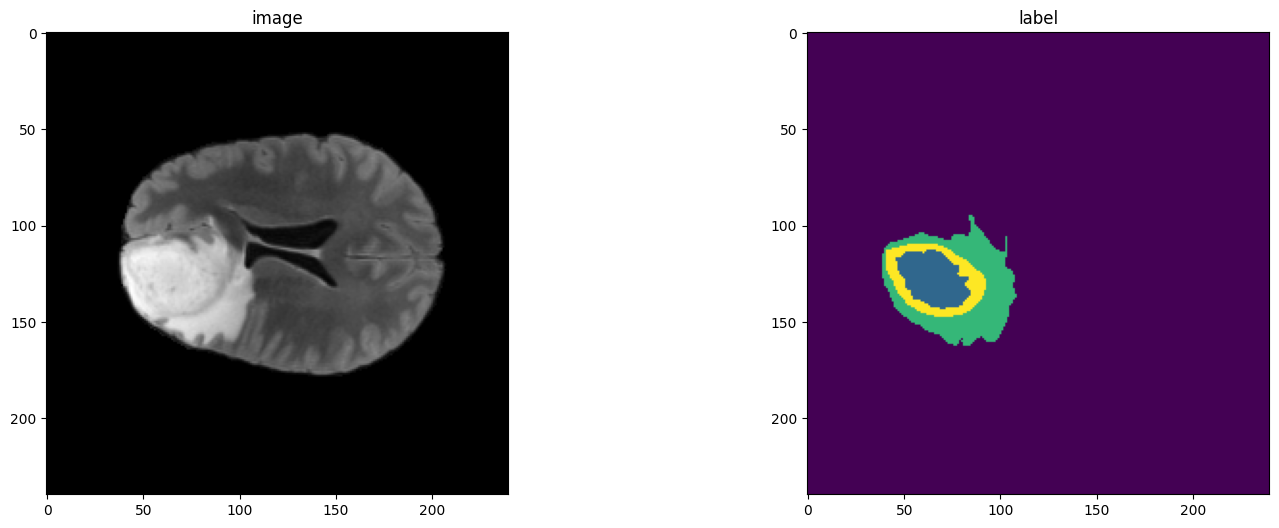

In [ ]:
case_num = "00006"
img_add = os.path.join(data_dir, "ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/BraTS-GLI-" + case_num + "-000/BraTS-GLI-" + case_num + "-000-t2f.nii.gz")
label_add = os.path.join(data_dir, "ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/BraTS-GLI-" + case_num + "-000/BraTS-GLI-" + case_num + "-000-seg.nii.gz")
img = nib.load(img_add).get_fdata()
label = nib.load(label_add).get_fdata()
print(f"image shape: {img.shape}, label shape: {label.shape}")
plt.figure("image", (18, 6))
plt.subplot(1, 2, 1)
plt.title("image")
plt.imshow(img[:, :, 78], cmap="gray")
plt.subplot(1, 2, 2)
plt.title("label")
plt.imshow(label[:, :, 78])
plt.show()

## Dual decoder unet


In [ ]:
import torch
import torch.nn as nn
from typing import Sequence, Union, Tuple
from monai.networks.blocks import Convolution, ResidualUnit
from monai.networks.layers import Act, Norm

In [ ]:
import torch
import torch.nn as nn
from typing import Sequence, Union, Tuple
from monai.networks.blocks import Convolution, ResidualUnit
from monai.networks.layers import Act, Norm

class ConfigurableDualHeadUNet(nn.Module):
    def __init__(
        self,
        spatial_dims: int = 3,
        in_channels: int = 4,
        out_channels: int = 3,
        channels: Sequence[int] = (16, 32, 64, 128, 256),
        strides: Sequence[int] = (2, 2, 2, 2),
        num_res_units: int = 2,
        act: Union[Tuple, str] = Act.PRELU,
        norm: Union[Tuple, str] = Norm.INSTANCE,
        dropout: float = 0.0,
    ):
        super().__init__()
        self.spatial_dims = spatial_dims
        self.num_res_units = num_res_units
        self.act = act
        self.norm = norm
        self.dropout = dropout

        if len(channels) < 2:
            raise ValueError("`channels` must have at least 2 values.")
        if len(strides) != len(channels) - 1:
            raise ValueError("`strides` length must be exactly `len(channels) - 1`.")

        self.encoder_layers = nn.ModuleList()
        current_inc = in_channels

        # Track input channels for skip connection sizes
        # Skips are captured BEFORE the layer, so they correspond to the inputs of each encoder layer
        skip_channels_list = [in_channels]

        # Build Encoder
        for i, (c, s) in enumerate(zip(channels[:-1], strides)):
            layer = self._make_layer(current_inc, c, s, False)
            self.encoder_layers.append(layer)
            current_inc = c
            # The input to the NEXT layer will be 'c', so that's the skip size for the next level
            if i < len(channels) - 2:
                skip_channels_list.append(c)

        # Bottleneck
        self.bottleneck = self._make_layer(current_inc, channels[-1], 1, False)
        bottleneck_channels = channels[-1]

        self.seg_decoder_layers = nn.ModuleList()
        self.geo_decoder_layers = nn.ModuleList()

        current_dec_c = bottleneck_channels
        rev_channels = channels[:-1][::-1]
        rev_strides = strides[::-1]

        # Reverse skip channels to match decoder order (deepest to shallowest)
        rev_skip_channels = skip_channels_list[::-1]

        # Build Decoder
        for i, (c, s, skip_c) in enumerate(zip(rev_channels, rev_strides, rev_skip_channels)):
            self.seg_decoder_layers.append(self._make_up_layer(current_dec_c, c, s, skip_c))
            self.geo_decoder_layers.append(self._make_up_layer(current_dec_c, c, s, skip_c))
            current_dec_c = c

        self.seg_head = Convolution(spatial_dims, current_dec_c, out_channels, kernel_size=1, strides=1, act=None, norm=None, conv_only=True)
        self.geo_head = Convolution(spatial_dims, current_dec_c, out_channels, kernel_size=1, strides=1, act=None, norm=None, conv_only=True)

    def _make_layer(self, in_channels, out_channels, strides, is_transposed):
        if self.num_res_units > 0:
            return ResidualUnit(self.spatial_dims, in_channels, out_channels, strides, kernel_size=3, subunits=self.num_res_units, act=self.act, norm=self.norm, dropout=self.dropout)
        else:
            return Convolution(self.spatial_dims, in_channels, out_channels, strides, kernel_size=3, act=self.act, norm=self.norm, dropout=self.dropout, is_transposed=is_transposed)

    def _make_up_layer(self, in_channels, out_channels, strides, skip_channels):
        """
        Modified to accept skip_channels explicitly.
        Refine layer input is now: out_channels (from upsample) + skip_channels (from encoder)
        """
        upsample = Convolution(self.spatial_dims, in_channels, out_channels, strides, kernel_size=3, act=self.act, norm=self.norm, dropout=self.dropout, is_transposed=True)

        # Refine block handles the concatenation of upsampled features + skip connection
        concat_channels = out_channels + skip_channels
        refine = self._make_layer(concat_channels, out_channels, 1, False)

        return nn.ModuleDict({"upsample": upsample, "refine": refine})

    def forward(self, x):
        skips = []
        for layer in self.encoder_layers:
            skips.append(x)  # FIX: Save input BEFORE striding/downsampling
            x = layer(x)

        bottleneck = self.bottleneck(x)
        x_seg = bottleneck
        x_geo = bottleneck

        # Iterate in reverse
        for i, skip in enumerate(reversed(skips)):
            # Segmentation path
            seg_ops = self.seg_decoder_layers[i]
            x_seg = seg_ops["upsample"](x_seg)

            # Ensure spatial dimensions match (handle minor rounding issues if needed, though strides=2 usually aligns well)
            if x_seg.shape[2:] != skip.shape[2:]:
                x_seg = transforms.Resize(spatial_size=skip.shape[2:])(x_seg)

            x_seg = torch.cat([x_seg, skip], dim=1)
            x_seg = seg_ops["refine"](x_seg)

            # Geodesic path
            geo_ops = self.geo_decoder_layers[i]
            x_geo = geo_ops["upsample"](x_geo)

            # Use same spatial check or assume symmetry
            x_geo = torch.cat([x_geo, skip], dim=1)
            x_geo = geo_ops["refine"](x_geo)

        seg_out = self.seg_head(x_seg)
        geo_out = torch.tanh(self.geo_head(x_geo))
        return seg_out, geo_out

## Novel loss function

$$
\mathcal{L}_{\text{total}} =
\frac{1}{2\sigma_{\text{seg}}^{2}} \mathcal{L}_{\text{Dice}}
+ \frac{1}{2\sigma_{\text{geo}}^{2}} \mathcal{L}_{\text{FocalL1}}
+ \frac{1}{2\sigma_{\text{con}}^{2}} \mathcal{L}_{\text{con}}
+ \log(\sigma_{\text{seg}})
+ \log(\sigma_{\text{geo}})
+ \log(\sigma_{\text{con}})
$$

In [ ]:
class UncertaintyWeightedMultiTaskLoss(nn.Module):
    def __init__(
        self,
        consistency_k_start=10.0,
        consistency_k_end=150.0,
        total_epochs=200,
        log_var_min: float = -4.0,
        log_var_max: float = 4.0,
        log_var_reg_weight: float = 0.005,
        freeze_con_var_after: float = 0.8,
    ):
        super().__init__()
        self.log_var_min = log_var_min
        self.log_var_max = log_var_max
        self.log_var_reg_weight = log_var_reg_weight
        self.freeze_con_var_after = freeze_con_var_after

        self.dice_loss = DiceLoss(sigmoid=True, squared_pred=True, batch=True, include_background=True)
        self.reg_loss = nn.L1Loss()

        self.k_start = consistency_k_start
        self.k_end = consistency_k_end
        self.total_epochs = total_epochs
        self.current_epoch = 0

        self.log_vars = nn.Parameter(torch.tensor([-0.087485, -0.093260, 2.874004]))

    def get_current_k(self):
        if self.current_epoch >= self.total_epochs:
            return self.k_end
        ratio = self.current_epoch / float(self.total_epochs)
        return self.k_start + (self.k_end - self.k_start) * ratio

    def step_epoch(self):
        self.current_epoch += 1
        freeze_epoch = int(self.freeze_con_var_after * self.total_epochs)
        if self.current_epoch == freeze_epoch:
            self.log_vars.requires_grad_(False)
            self.log_vars_seg_geo = nn.Parameter(self.log_vars[:2].clone())
            print(f"[Epoch {self.current_epoch}] log_vars[2] (consistency) frozen. Current value: {self.log_vars[2].item():.4f}")

    def _get_stable_log_vars(self):
        return self.log_vars.clamp(min=self.log_var_min, max=self.log_var_max)

    def forward(self, pred_seg_logits, pred_geo, true_seg, true_geo):
        loss_seg_raw = self.dice_loss(pred_seg_logits, true_seg)
        loss_geo_raw = self.reg_loss(pred_geo, true_geo)

        k = self.get_current_k()
        pred_seg_prob = torch.sigmoid(pred_seg_logits)
        soft_mask_from_geo = torch.sigmoid(k * pred_geo.detach())
        loss_con_raw = torch.mean((pred_seg_prob - soft_mask_from_geo) ** 2)

        lv = self._get_stable_log_vars()
        precisions = torch.exp(-lv)

        loss_seg_weighted = 0.5 * precisions[0] * loss_seg_raw + 0.5 * lv[0]
        loss_geo_weighted = 0.5 * precisions[1] * loss_geo_raw + 0.5 * lv[1]
        loss_con_weighted = 0.5 * precisions[2] * loss_con_raw + 0.5 * lv[2]

        log_var_reg = self.log_var_reg_weight * self.log_vars.pow(2).sum()

        total_loss = loss_seg_weighted + loss_geo_weighted + loss_con_weighted + log_var_reg
        weights = [(0.5 * p).item() for p in precisions]

        return total_loss, {
            "loss_seg":     loss_seg_raw.item(),
            "loss_geo":     loss_geo_raw.item(),
            "loss_con":     loss_con_raw.item(),
            "weight_seg":   weights[0],
            "weight_geo":   weights[1],
            "weight_con":   weights[2],
            "log_var_seg":  self.log_vars[0].item(),
            "log_var_geo":  self.log_vars[1].item(),
            "log_var_con":  self.log_vars[2].item(),
            "current_k":    k,
        }

## Initilaizing the model

| Stage | Block Name | Operation | In | Out | Str. | Skip Connection |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **Encoder** | Encoder Block 1 | 2x Residual Units | 4 | 16 | 2 | Saved for Decoder 4 |
| | Encoder Block 2 | 2x Residual Units | 16 | 32 | 2 | Saved for Decoder 3 |
| | Encoder Block 3 | 2x Residual Units | 32 | 64 | 2 | Saved for Decoder 2 |
| | Encoder Block 4 | 2x Residual Units | 64 | 128 | 2 | Saved for Decoder 1 |
| **Bottleneck** | Bottleneck Block | 2x Residual Units | 128 | 256 | 1 | None |
| **Decoder (Both Branches)** | Decoder Block 1 | Upsample + Concat + Refine | 256 | 128 | 2 | Receives from Encoder 4 |
| | Decoder Block 2 | Upsample + Concat + Refine | 128 | 64 | 2 | Receives from Encoder 3 |
| | Decoder Block 3 | Upsample + Concat + Refine | 64 | 32 | 2 | Receives from Encoder 2 |
| | Decoder Block 4 | Upsample + Concat + Refine | 32 | 16 | 2 | Receives from Encoder 1 |
| **Output** | Segmentation Head | 1x1 Convolution | 16 | 3 | 1 | None |
| | Geodesic Head | 1x1 Conv + Tanh | 16 | 3 | 1 | None |

In [ ]:
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize model
model = ConfigurableDualHeadUNet(
    spatial_dims=3,
    in_channels=4,
    out_channels=3,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
).to(device)

# model = torch.compile(model)

In [ ]:
total_params = sum(p.numel() for p in model.parameters())
log_print(f"Total model parameters: {total_params}", level="INFO", timestamp=True)

Total model parameters: 9211480


In [ ]:
print(model)

ConfigurableDualHeadUNet(
  (encoder_layers): ModuleList(
    (0): ResidualUnit(
      (conv): Sequential(
        (unit0): Convolution(
          (conv): Conv3d(4, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
          (adn): ADN(
            (N): InstanceNorm3d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
        (unit1): Convolution(
          (conv): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (adn): ADN(
            (N): InstanceNorm3d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
      )
      (residual): Conv3d(4, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
    )
    (1): ResidualUnit(
      (conv): Sequential(
        (unit0): Convolut

## Optimizer and loss function

In [ ]:
torch.backends.cudnn.benchmark = True

# Initialize loss
mtl_loss = UncertaintyWeightedMultiTaskLoss(
    consistency_k_start=10.0,
    consistency_k_end=150.0,
    total_epochs=max_epochs
).to(device)

# Setup metrics and inferer
post_sigmoid = Activations(sigmoid=True)
post_pred = AsDiscrete(argmax=False, threshold=0.5)
dice_acc = DiceMetric(include_background=True, reduction=MetricReduction.MEAN_BATCH, get_not_nans=True)

model_inferer = partial(
    sliding_window_inference,
    roi_size=[roi[0], roi[1], roi[2]],
    sw_batch_size=sw_batch_size,
    predictor=model,
    overlap=infer_overlap,
)

def dual_head_inferer(data):
    """Wrapper for sliding window inference with dual outputs"""
    seg_out, geo_out = sliding_window_inference(
        inputs=data,
        roi_size=roi,
        sw_batch_size=sw_batch_size,
        predictor=model,
        overlap=infer_overlap,
    )
    return seg_out, geo_out

# Optimizer and scheduler - Decoupled optimization for proposed loss
optimizer = torch.optim.AdamW([
    {"params": model.parameters(), "lr": 1e-4, "weight_decay": 1e-5},
    {"params": mtl_loss.parameters(), "lr": 1e-3, "weight_decay": 0.0}
])

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)

## Define Train and Validation Epoch

In [ ]:
from torch.amp import autocast, GradScaler

def train_epoch(model, loader, optimizer, epoch, loss_func, max_epochs, batch_size, scaler=None, clip_grad=False, clip_max_norm=1.0):
    model.train()
    start_time = time.time()

    # Meters
    run_loss_total = AverageMeter()
    run_loss_seg = AverageMeter()
    run_loss_geo = AverageMeter()
    run_loss_con = AverageMeter()
    run_weight_seg = AverageMeter()
    run_weight_geo = AverageMeter()
    run_weight_con = AverageMeter()

    # Uncertainty Meters
    run_log_var_seg = AverageMeter()
    run_log_var_geo = AverageMeter()
    run_log_var_con = AverageMeter()

    for idx, batch_data in enumerate(loader):
        data = batch_data["image"].cuda()
        # Cast targets to float (Fix for squared_pred=True)
        target_seg = batch_data["label"].cuda().float()
        target_geo = batch_data["geodesic_avg"].cuda().float()

        optimizer.zero_grad()

        # --- AMP Logic ---
        if scaler is not None:
            # MIXED PRECISION MODE
            with autocast("cuda", enabled=True):
                pred_seg_logits, pred_geo = model(data)
                total_loss, loss_dict = loss_func(pred_seg_logits, pred_geo, target_seg, target_geo)

            # Scale loss and unscale gradients
            scaler.scale(total_loss).backward()

            if clip_grad:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_max_norm)

            scaler.step(optimizer)
            scaler.update()
        else:
            # STANDARD FP32 MODE
            pred_seg_logits, pred_geo = model(data)
            total_loss, loss_dict = loss_func(pred_seg_logits, pred_geo, target_seg, target_geo)

            total_loss.backward()

            if clip_grad:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_max_norm)

            optimizer.step()
        # -----------------

        # Update metrics (Same as before)
        run_loss_total.update(total_loss.item(), n=batch_size)
        run_loss_seg.update(loss_dict["loss_seg"], n=batch_size)
        run_loss_geo.update(loss_dict["loss_geo"], n=batch_size)
        run_loss_con.update(loss_dict["loss_con"], n=batch_size)
        run_weight_seg.update(loss_dict["weight_seg"], n=batch_size)
        run_weight_geo.update(loss_dict["weight_geo"], n=batch_size)

        weight_con = loss_dict.get("weight_con", 0.0)
        run_weight_con.update(weight_con, n=batch_size)

        log_vars = loss_func.log_vars.data
        run_log_var_seg.update(log_vars[0].item(), n=batch_size)
        run_log_var_geo.update(log_vars[1].item(), n=batch_size)
        run_log_var_con.update(log_vars[2].item(), n=batch_size)

        log_print(
            f"Epoch {epoch}/{max_epochs} {idx}/{len(loader)} | "
            f"Total: {run_loss_total.avg:.4f} | "
            f"Seg: {run_loss_seg.avg:.4f} | "
            f"Geo: {run_loss_geo.avg:.4f} | "
            f"Con: {run_loss_con.avg:.4f} | "
            f"Time: {time.time() - start_time:.2f}s",
            level=None,
            timestamp=False # Epoch related things don't need timestamp
        )
        start_time = time.time()

    return {
        "total": run_loss_total.avg,
        "seg": run_loss_seg.avg,
        "geo": run_loss_geo.avg,
        "con": run_loss_con.avg,
        "w_seg": run_weight_seg.avg,
        "w_geo": run_weight_geo.avg,
        "w_con": run_weight_con.avg,
        "log_var_seg": run_log_var_seg.avg,
        "log_var_geo": run_log_var_geo.avg,
        "log_var_con": run_log_var_con.avg,
    }


def val_epoch(model, loader, epoch, acc_func, loss_func, model_inferer, post_sigmoid, post_pred, max_epochs, use_amp=False, writer=None):
    model.eval()
    start_time = time.time()

    run_acc = AverageMeter()
    # NEW: Meters for validation loss
    run_loss_total = AverageMeter()
    run_loss_seg = AverageMeter()
    run_loss_geo = AverageMeter()

    with torch.no_grad():
        for idx, batch_data in enumerate(loader):
            data = batch_data["image"].cuda()
            target = batch_data["label"].cuda().float()
            # NEW: Need geodesic target for loss calc
            target_geo = batch_data["geodesic_avg"].cuda().float()

            # --- AMP Logic for Validation ---
            if use_amp:
                with autocast("cuda", enabled=True):
                    # Capture BOTH outputs (seg and geo) from sliding window
                    logits, geo_pred = model_inferer(data)

                    # NEW: Calculate Loss
                    # We use the same loss function as training
                    val_loss, val_loss_dict = loss_func(logits, geo_pred, target, target_geo)
            else:
                logits, geo_pred = model_inferer(data)
                val_loss, val_loss_dict = loss_func(logits, geo_pred, target, target_geo)
            # --------------------------------

            # Update Loss Meters
            run_loss_total.update(val_loss.item())
            run_loss_seg.update(val_loss_dict["loss_seg"])
            run_loss_geo.update(val_loss_dict["loss_geo"])

            # Calculate Accuracy (Dice)
            val_labels_list = decollate_batch(target)
            val_outputs_list = decollate_batch(logits)
            val_output_convert = [
                post_pred(post_sigmoid(val_pred_tensor))
                for val_pred_tensor in val_outputs_list
            ]

            acc_func.reset()
            acc_func(y_pred=val_output_convert, y=val_labels_list)
            acc, not_nans = acc_func.aggregate()
            run_acc.update(acc.cpu().numpy(), n=not_nans.cpu().numpy())

            dice_tc = run_acc.avg[0]
            dice_wt = run_acc.avg[1]
            dice_et = run_acc.avg[2]

            log_print(
                f"Val {epoch}/{max_epochs} {idx}/{len(loader)} | "
                f"Loss: {run_loss_total.avg:.4f} | " # Show loss in log
                f"TC: {dice_tc:.4f}, WT: {dice_wt:.4f}, ET: {dice_et:.4f} | "
                f"Time: {time.time() - start_time:.2f}s",
                level="INFO",
                timestamp=False
            )
            start_time = time.time()

            # --- TENSORBOARD IMAGE VISUALIZATION (Log 1st batch only) ---
            if writer is not None and idx == 0:
                mid_slice = data.shape[-1] // 2
                img_slice = data[:, 0, :, :, mid_slice].unsqueeze(1)
                target_slice = torch.max(target[:, :, :, :, mid_slice], dim=1, keepdim=True)[0]
                pred_slice = torch.sigmoid(logits[:, :, :, :, mid_slice])
                pred_slice = torch.max(pred_slice, dim=1, keepdim=True)[0]

                writer.add_images("Val/Image", img_slice, epoch)
                writer.add_images("Val/GroundTruth", target_slice, epoch)
                writer.add_images("Val/Prediction", pred_slice, epoch)

    # Return avg accuracy scores AND avg loss dict
    return run_acc.avg, {
        "val_total": run_loss_total.avg,
        "val_seg": run_loss_seg.avg,
        "val_geo": run_loss_geo.avg
    }

##Training loop

In [ ]:
import os
import time
import numpy as np
import torch
from torch.utils.tensorboard import SummaryWriter

def trainer(
    model, train_loader, val_loader, optimizer, loss_func, acc_func,
    scheduler, model_inferer, post_sigmoid, post_pred, max_epochs,
    val_every, checkpoint_dir=".", use_amp=False, use_compile=True,
    clip_grad=False, clip_max_norm=1.0
):
    """
    Training loop with proper checkpoint handling and validation loss tracking.
    """
    writer = SummaryWriter(log_dir=os.path.join(checkpoint_dir, "runs"))

    history = initialize_history()
    start_epoch = 0
    val_acc_max = 0.0

    scaler = GradScaler() if use_amp else None

    log_print("\n" + "="*80, level="INFO", timestamp=True)
    log_print("TRAINING CONFIGURATION", level="INFO", timestamp=True)
    log_print("="*80, level="INFO", timestamp=True)
    log_print(f"Max Epochs:        {max_epochs}", level="INFO", timestamp=True)
    log_print(f"Validation Every:  {val_every} epochs", level="INFO", timestamp=True)
    log_print(f"Checkpoint Dir:    {checkpoint_dir}", level="INFO", timestamp=True)
    log_print(f"Mixed Precision:   {'Enabled' if use_amp else 'Disabled'}", level="INFO", timestamp=True)
    log_print(f"Model Compilation: {'Enabled' if use_compile else 'Disabled'}", level="INFO", timestamp=True)
    log_print(f"Gradient Clipping: {'Enabled (max_norm=' + str(clip_max_norm) + ')' if clip_grad else 'Disabled'}", level="INFO", timestamp=True)
    log_print("="*80 + "\n", level="INFO", timestamp=True)

    # load checkpoints
    resume_path = os.path.join(checkpoint_dir, "model_last.pt")
    if os.path.exists(resume_path):
        log_print(f"Found existing checkpoint: {resume_path}", level="INFO", timestamp=True)
        result = load_checkpoint(
            model, optimizer, scheduler,
            loss_func=loss_func,
            scaler=scaler,
            filename=resume_path
        )
        if result:
            start_epoch, val_acc_max, history = result
            loss_func.current_epoch = start_epoch
            log_print(f"Successfully resumed training from epoch {start_epoch}", level="INFO", timestamp=True)

            # --- TENSORBOARD BACKFILL ---
            if len(history["trains_epoch"]) > 0:
                log_print(f"Restoring history to TensorBoard...", level="INFO", timestamp=True)
                for i, ep in enumerate(history["trains_epoch"]):
                    # Training Metrics
                    if i < len(history["loss_total"]):
                        writer.add_scalar("Loss/Total", history["loss_total"][i], ep)
                        writer.add_scalar("Loss/Seg", history["loss_seg"][i], ep)
                        writer.add_scalar("Loss/Geo", history["loss_geo"][i], ep)
                        writer.add_scalar("Loss/Con", history["loss_con"][i], ep)
                        writer.add_scalar("Weights/Seg", history["weight_seg"][i], ep)
                        writer.add_scalar("Weights/Geo", history["weight_geo"][i], ep)
                        writer.add_scalar("Weights/Con", history["weight_con"][i], ep)

                    # Backfill Validation Metrics
                    # Note: Since validation doesn't run every epoch, we iterate carefully
                    if "val_loss_total" in history and i < len(history["val_loss_total"]):
                         # Note: This simplistic mapping assumes val_loss_total aligns with trains_epoch
                         # Ideally, you'd track 'val_epochs' separately, but if you always append
                         # to both lists in sync during the loop, this logic is safer:
                         pass
                log_print("History restored.", level="INFO", timestamp=True)
            # -----------------------------
        else:
            log_print("WARNING: Failed to load checkpoint - starting from scratch", level="WARNING", timestamp=True)
    else:
        log_print("No checkpoint found - starting fresh training", level="INFO", timestamp=True)
        if "val_acc_max" in history:
            val_acc_max = history["val_acc_max"]

    if use_compile and hasattr(torch, "compile"):
        log_print("\nCompiling model for optimized training...", level="INFO", timestamp=True)
        model = torch.compile(model)
        log_print("Model compilation complete", level="INFO", timestamp=True)

    ## Training loop
    log_print("\n" + "="*80, level="INFO", timestamp=True)
    log_print("STARTING TRAINING", level="INFO", timestamp=True)
    log_print("="*80 + "\n", level="INFO", timestamp=True)

    for epoch in range(start_epoch, max_epochs):
        log_print("\n" + "-"*80, level="INFO", timestamp=False)
        current_k = loss_func.get_current_k()
        log_print(f"EPOCH {epoch}/{max_epochs-1} | k={current_k:.1f} | {time.ctime()}", level="INFO", timestamp=False)
        log_print("-"*80, level="INFO", timestamp=False)

        writer.add_scalar("Train/LearningRate", optimizer.param_groups[0]['lr'], epoch)
        writer.add_scalar("Train/Consistency_K", current_k, epoch)

        epoch_time = time.time()

        # Training phase
        train_metrics = train_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            epoch=epoch,
            loss_func=loss_func,
            max_epochs=max_epochs,
            batch_size=train_loader.batch_size,
            scaler=scaler,
            clip_grad=clip_grad,
            clip_max_norm=clip_max_norm
        )

        train_time = time.time() - epoch_time

        log_print(f"\n{f'Epoch: {epoch} Training Summary':^80}", level="INFO", timestamp=False)
        log_print("-"*80, level="INFO", timestamp=False)
        log_print(f"  Total Loss:  {train_metrics['total']:.4f}", level="INFO", timestamp=False)
        log_print(f"  Seg Loss:    {train_metrics['seg']:.4f}  (weight: {train_metrics['w_seg']:.4f})", level="INFO", timestamp=False)
        log_print(f"  Geo Loss:    {train_metrics['geo']:.4f}  (weight: {train_metrics['w_geo']:.4f})", level="INFO", timestamp=False)
        log_print(f"  Con Loss:    {train_metrics['con']:.4f}  (weight: {train_metrics['w_con']:.4f})", level="INFO", timestamp=False)
        log_print(f"  Time:        {train_time:.2f}s", level="INFO", timestamp=False)
        log_print("-"*80, level="INFO", timestamp=False)

        # --- LOGGING TO TENSORBOARD (Scalars) ---
        writer.add_scalar("Loss/Total", train_metrics['total'], epoch)
        writer.add_scalar("Loss/Seg", train_metrics['seg'], epoch)
        writer.add_scalar("Loss/Geo", train_metrics['geo'], epoch)
        writer.add_scalar("Loss/Con", train_metrics['con'], epoch)
        writer.add_scalar("Weights/Seg", train_metrics['w_seg'], epoch)
        writer.add_scalar("Weights/Geo", train_metrics['w_geo'], epoch)
        writer.add_scalar("Weights/Con", train_metrics['w_con'], epoch)

        # UPDATE HISTORY
        history["loss_total"].append(train_metrics["total"])
        history["loss_seg"].append(train_metrics["seg"])
        history["loss_geo"].append(train_metrics["geo"])
        history["loss_con"].append(train_metrics["con"])

        history["weight_seg"].append(train_metrics["w_seg"])
        history["weight_geo"].append(train_metrics["w_geo"])
        history["weight_con"].append(train_metrics["w_con"])

        history["log_var_seg"].append(train_metrics["log_var_seg"])
        history["log_var_geo"].append(train_metrics["log_var_geo"])
        history["log_var_con"].append(train_metrics["log_var_con"])

        history["sigma_seg"].append(np.sqrt(np.exp(train_metrics["log_var_seg"])))
        history["sigma_geo"].append(np.sqrt(np.exp(train_metrics["log_var_geo"])))
        history["sigma_con"].append(np.sqrt(np.exp(train_metrics["log_var_con"])))

        history["trains_epoch"].append(int(epoch))

        is_best = False

        # Validation Logic
        if (epoch + 1) % val_every == 0 or epoch == 0 or (epoch == max_epochs - 1):
            log_print(f"\n{'VALIDATION':^80}", level="INFO", timestamp=False)
            log_print("-"*80, level="INFO", timestamp=False)
            val_start = time.time()

            # Run Validation
            val_acc_scores, val_loss_dict = val_epoch(
                model=model,
                loader=val_loader,
                epoch=epoch,
                acc_func=acc_func,
                loss_func=loss_func,  # <--- Passing loss_func now
                model_inferer=model_inferer,
                post_sigmoid=post_sigmoid,
                post_pred=post_pred,
                max_epochs=max_epochs,
                use_amp=use_amp,
                writer=writer
            )

            # Unpack Accuracy
            dice_tc, dice_wt, dice_et = val_acc_scores[0], val_acc_scores[1], val_acc_scores[2]
            val_avg_acc = np.mean(val_acc_scores)
            val_time = time.time() - val_start

            log_print("-"*80, level="INFO", timestamp=False)
            log_print(f"  Val Total Loss: {val_loss_dict['val_total']:.4f}", level="INFO", timestamp=False)
            log_print(f"  Dice TC:        {dice_tc:.4f}", level="INFO", timestamp=False)
            log_print(f"  Dice WT:        {dice_wt:.4f}", level="INFO", timestamp=False)
            log_print(f"  Dice ET:        {dice_et:.4f}", level="INFO", timestamp=False)
            log_print(f"  Dice AVG:       {val_avg_acc:.4f}", level="INFO", timestamp=False)
            log_print(f"  Time:           {val_time:.2f}s", level="INFO", timestamp=False)
            log_print("-"*80, level="INFO", timestamp=False)

            # --- LOGGING TO TENSORBOARD (Validation) ---
            writer.add_scalar("Val/Dice_Avg", val_avg_acc, epoch)
            writer.add_scalar("Val/Dice_TC", dice_tc, epoch)
            writer.add_scalar("Val/Dice_WT", dice_wt, epoch)
            writer.add_scalar("Val/Dice_ET", dice_et, epoch)

            # NEW: Log Validation Loss
            writer.add_scalar("Val/Loss_Total", val_loss_dict["val_total"], epoch)
            writer.add_scalar("Val/Loss_Seg", val_loss_dict["val_seg"], epoch)
            writer.add_scalar("Val/Loss_Geo", val_loss_dict["val_geo"], epoch)
            # -------------------------------------------

            # Update History with Val Metrics
            history["dices_tc"].append(dice_tc)
            history["dices_wt"].append(dice_wt)
            history["dices_et"].append(dice_et)
            history["dices_avg"].append(val_avg_acc)

            # NEW: Append Val Losses
            if "val_loss_total" not in history: history["val_loss_total"] = []
            if "val_loss_seg" not in history: history["val_loss_seg"] = []
            if "val_loss_geo" not in history: history["val_loss_geo"] = []

            history["val_loss_total"].append(val_loss_dict["val_total"])
            history["val_loss_seg"].append(val_loss_dict["val_seg"])
            history["val_loss_geo"].append(val_loss_dict["val_geo"])

            # Check if best model
            is_best = val_avg_acc > val_acc_max
            if is_best:
                improvement = val_avg_acc - val_acc_max
                log_print(f"\n*** NEW BEST MODEL ***", level="INFO", timestamp=False)
                log_print(f"    Previous best: {val_acc_max:.4f}", level="INFO", timestamp=False)
                log_print(f"    Current:       {val_avg_acc:.4f}", level="INFO", timestamp=False)
                log_print(f"    Improvement:   +{improvement:.4f}", level="INFO", timestamp=False)
                val_acc_max = val_avg_acc
                history["val_acc_max"] = val_acc_max

        # Save Checkpoint EVERY EPOCH
        log_print(f"\nSaving checkpoint...", level="INFO", timestamp=False)
        save_checkpoint(
            model, epoch, optimizer, scheduler, history, val_acc_max,
            loss_func=loss_func,
            scaler=scaler,
            dir_add=checkpoint_dir,
            is_best=is_best
        )

        scheduler.step()
        loss_func.step_epoch()
        log_print(f"\nLearning rate: {scheduler.get_last_lr()[0]:.6f}", level="INFO", timestamp=False)

    log_print("\n" + "="*80, level="INFO", timestamp=True)
    log_print("TRAINING COMPLETE", level="INFO", timestamp=True)
    log_print("="*80, level="INFO", timestamp=True)
    log_print(f"Best Validation Dice: {val_acc_max:.4f}", level="INFO", timestamp=True)
    log_print(f"Total Epochs:         {max_epochs}", level="INFO", timestamp=True)
    log_print("="*80 + "\n", level="INFO", timestamp=True)

    writer.flush()
    writer.close()

    return history

In [ ]:
# import shutil
# # Clear the cache directory to force re-processing of data
# if os.path.exists("/content/persistent_cache"):
#     shutil.rmtree("/content/persistent_cache")
#     print("Cache cleared!")
# os.makedirs("/content/persistent_cache", exist_ok=True)

## Launching tensorboard

In [ ]:
!mkdir -p /workspace/monai_data/dual_decoder_UNet/runs

In [ ]:
import subprocess
import os

log_dir = "/workspace/monai_data/dual_decoder_UNet/runs"
# Create the directory if it doesn't exist yet
os.makedirs(log_dir, exist_ok=True)

# Launch TensorBoard as a background process
cmd = [
    "tensorboard",
    "--logdir", log_dir,
    "--port", "6007",
    "--bind_all"
]

# This starts the process and lets the notebook move on immediately
with open("tensorboard_log.txt", "w") as f:
    subprocess.Popen(cmd, stdout=f, stderr=f)

print("TensorBoard started in the background on port 6007.")

TensorBoard started in the background on port 6007.


In [ ]:
!ps aux | grep tensorboard

root        2960  7.0  0.0 3468708 79724 ?       Sl   08:19   0:01 /usr/bin/python /usr/local/bin/tensorboard --logdir /workspace/monai_data/dual_decoder_UNet/runs --port 6007 --bind_all
root        3008  0.0  0.0 1030184 7824 ?        Sl   08:19   0:00 /usr/local/lib/python3.11/dist-packages/tensorboard_data_server/bin/server --logdir=/workspace/monai_data/dual_decoder_UNet/runs --reload=5 --samples-per-plugin= --port=0 --port-file=/tmp/tensorboard_data_server_38013l4k/port --die-after-stdin --error-file=/tmp/tensorboard_data_server_38013l4k/startup_error
root        3136  0.0  0.0   4740  2696 pts/0    Ss+  08:19   0:00 /bin/bash -c ps aux | grep tensorboard
root        3138  0.0  0.0   3848  1928 pts/0    S+   08:19   0:00 grep tensorboard


In [ ]:
POD_ID = os.environ.get('RUNPOD_POD_ID')
POD_ID

'xueogmqp7uvza8'

## Execute training

In [ ]:
train_loader, val_loader = get_loader(batch_size, data_dir, json_list, fold, roi, debug_mode)

In [ ]:
try:
history = trainer(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        loss_func=mtl_loss,
        acc_func=dice_acc,
        scheduler=scheduler,
        model_inferer=model_inferer,
        post_sigmoid=post_sigmoid,
        post_pred=post_pred,
        max_epochs=max_epochs,
        val_every=val_every,
        checkpoint_dir=root_dir,
        use_amp=True,
        use_compile=True,
        clip_grad=True,       # <--- Turn Gradient Clipping ON
        clip_max_norm=1.0
    )
except Exception as e:
    log_print("CRITICAL ERROR ENCOUNTERED DURING TRAINING", level="ERROR", timestamp=True)
    log_print(traceback.format_exc(), level="ERROR", timestamp=True)
    raise e  # Halt execution

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

def plot_training_curves(history, val_every=5, save_dir=None, n=None):
    """
    Standard training visualization (no clipping or smoothing).
    Shows true loss dynamics including spikes.
    Prints the initial uncertainty parameters for resuming training.
    Visualizes up to epoch 'n' if provided.
    """

    sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
    colors = sns.color_palette("Set2")

    def _to_numpy(arr):
        return np.array(arr, dtype=float).flatten()

    # --- NEW: Print Initial Parameters ---
    print("\n" + "="*50)
    print(" INITIAL MULTI-TASK UNCERTAINTY PARAMETERS")
    print("="*50)

    try:
        # Extract the very first epoch's values
        init_lv_seg = _to_numpy(history["log_var_seg"])[0]
        init_lv_geo = _to_numpy(history["log_var_geo"])[0]
        init_lv_con = _to_numpy(history["log_var_con"])[0]

        print(f"Log Variance (Segmentation) : {init_lv_seg:.6f}")
        print(f"Log Variance (Geodesic)     : {init_lv_geo:.6f}")
        print(f"Log Variance (Consistency)  : {init_lv_con:.6f}")
        print("-" * 50)

        if "weight_seg" in history:
            init_w_seg = _to_numpy(history["weight_seg"])[0]
            init_w_geo = _to_numpy(history["weight_geo"])[0]
            init_w_con = _to_numpy(history["weight_con"])[0]

            print(f"Derived Weight (Segmentation) : {init_w_seg:.6f}")
            print(f"Derived Weight (Geodesic)     : {init_w_geo:.6f}")
            print(f"Derived Weight (Consistency)  : {init_w_con:.6f}")

    except (KeyError, IndexError) as e:
        print(f"Could not extract initial parameters. Missing key or empty history: {e}")
    print("="*50 + "\n")
    # -------------------------------------

    epochs = _to_numpy(history["trains_epoch"])

    val_len = len(history["dices_avg"])
    expected_val_epochs = [e for e in epochs if (e + 1) % val_every == 0 or e == 0 or e == epochs[-1]]

    if len(expected_val_epochs) == val_len:
        val_epochs = np.array(expected_val_epochs, dtype=float)
    else:
        val_epochs = np.linspace(epochs[0], epochs[-1], val_len)

    # --- TRUNCATE UP TO EPOCH 'N' ---
    if n is not None:
        train_mask = epochs <= n
        val_mask = val_epochs <= n

        epochs = epochs[train_mask]
        val_epochs = val_epochs[val_mask]
    else:
        # Create masks of all True if n is not defined
        train_mask = np.ones_like(epochs, dtype=bool)
        val_mask = np.ones_like(val_epochs, dtype=bool)

    # --- FIGURE 1: LOSSES ---
    fig1, axes1 = plt.subplots(2, 2, figsize=(14, 10))
    fig1.suptitle("Training & Validation Losses", fontsize=16, fontweight='bold', y=1.02)

    # Total Loss
    sns.lineplot(x=epochs, y=_to_numpy(history["loss_total"])[train_mask],
                 ax=axes1[0, 0], label="Train", color=colors[0], linewidth=2)
    if "val_loss_total" in history:
        sns.lineplot(x=val_epochs, y=_to_numpy(history["val_loss_total"])[val_mask],
                     ax=axes1[0, 0], label="Validation", color=colors[0],
                     linestyle="--", linewidth=2)
    axes1[0, 0].set(title="Total Loss", xlabel="Epoch", ylabel="Loss")

    # Seg Loss
    sns.lineplot(x=epochs, y=_to_numpy(history["loss_seg"])[train_mask],
                 ax=axes1[0, 1], label="Train", color=colors[1], linewidth=2)
    if "val_loss_seg" in history:
        sns.lineplot(x=val_epochs, y=_to_numpy(history["val_loss_seg"])[val_mask],
                     ax=axes1[0, 1], label="Validation", color=colors[1],
                     linestyle="--", linewidth=2)
    axes1[0, 1].set(title="Segmentation Loss", xlabel="Epoch", ylabel="Loss")

    # Geo Loss
    sns.lineplot(x=epochs, y=_to_numpy(history["loss_geo"])[train_mask],
                 ax=axes1[1, 0], label="Train", color=colors[2], linewidth=2)
    if "val_loss_geo" in history:
        sns.lineplot(x=val_epochs, y=_to_numpy(history["val_loss_geo"])[val_mask],
                     ax=axes1[1, 0], label="Validation", color=colors[2],
                     linestyle="--", linewidth=2)
    axes1[1, 0].set(title="Geodesic Loss", xlabel="Epoch", ylabel="Loss")

    # Consistency Loss
    sns.lineplot(x=epochs, y=_to_numpy(history["loss_con"])[train_mask],
                 ax=axes1[1, 1], color=colors[3], linewidth=2)
    axes1[1, 1].set(title="Consistency Loss", xlabel="Epoch", ylabel="Loss")

    plt.tight_layout()
    if save_dir:
        plt.savefig(os.path.join(save_dir, "loss_curves.png"), dpi=300, bbox_inches='tight')
        plt.savefig(os.path.join(save_dir, "loss_curves.svg"), bbox_inches='tight')
    plt.show()

    # --- FIGURE 2: VALIDATION DICE SCORES ---
    fig2, ax2 = plt.subplots(figsize=(10, 6))

    sns.lineplot(x=val_epochs, y=_to_numpy(history["dices_tc"])[val_mask], label="Tumor Core (TC)", linewidth=2.5)
    sns.lineplot(x=val_epochs, y=_to_numpy(history["dices_wt"])[val_mask], label="Whole Tumor (WT)", linewidth=2.5)
    sns.lineplot(x=val_epochs, y=_to_numpy(history["dices_et"])[val_mask], label="Enhancing Tumor (ET)", linewidth=2.5)
    sns.lineplot(x=val_epochs, y=_to_numpy(history["dices_avg"])[val_mask],
                 label="Average Dice", color='k', linestyle="--", linewidth=2.5)

    ax2.set_title("Validation Dice Scores over Epochs", fontsize=16, fontweight='bold')
    ax2.set(xlabel="Epoch", ylabel="Dice Coefficient")
    ax2.legend(loc="lower right")

    plt.tight_layout()
    if save_dir:
        plt.savefig(os.path.join(save_dir, "dice_scores.png"), dpi=300, bbox_inches='tight')
        plt.savefig(os.path.join(save_dir, "dice_scores.svg"), bbox_inches='tight')
    plt.show()

    # --- FIGURE 3: UNCERTAINTY PARAMETERS ---
    fig3, axes3 = plt.subplots(3, 1, figsize=(12, 12))
    fig3.suptitle("Multi-Task Learning Uncertainty Parameters", fontsize=16, fontweight='bold', y=1.02)

    sns.lineplot(x=epochs, y=_to_numpy(history["log_var_seg"])[train_mask], ax=axes3[0], label="Segmentation", linewidth=2)
    sns.lineplot(x=epochs, y=_to_numpy(history["log_var_geo"])[train_mask], ax=axes3[0], label="Geodesic", linewidth=2)
    sns.lineplot(x=epochs, y=_to_numpy(history["log_var_con"])[train_mask], ax=axes3[0], label="Consistency", linewidth=2)
    axes3[0].set(title=r"Learned Log Variances $log(\sigma^2)$", xlabel="Epoch", ylabel=r"$log(\sigma^2)$")

    sns.lineplot(x=epochs, y=_to_numpy(history["sigma_seg"])[train_mask], ax=axes3[1], label="Segmentation", linewidth=2)
    sns.lineplot(x=epochs, y=_to_numpy(history["sigma_geo"])[train_mask], ax=axes3[1], label="Geodesic", linewidth=2)
    sns.lineplot(x=epochs, y=_to_numpy(history["sigma_con"])[train_mask], ax=axes3[1], label="Consistency", linewidth=2)
    axes3[1].set(title=r"Derived Uncertainty ($\sigma$)", xlabel="Epoch", ylabel=r"$\sigma$")

    sns.lineplot(x=epochs, y=_to_numpy(history["weight_seg"])[train_mask], ax=axes3[2], label="Segmentation", linewidth=2)
    sns.lineplot(x=epochs, y=_to_numpy(history["weight_geo"])[train_mask], ax=axes3[2], label="Geodesic", linewidth=2)
    sns.lineplot(x=epochs, y=_to_numpy(history["weight_con"])[train_mask], ax=axes3[2], label="Consistency", linewidth=2)
    axes3[2].set(title=r"Task Weights (Precision = $1 / 2\sigma^2$)", xlabel="Epoch", ylabel="Weight")

    plt.tight_layout()
    if save_dir:
        plt.savefig(os.path.join(save_dir, "uncertainty_params.png"), dpi=300, bbox_inches='tight')
        plt.savefig(os.path.join(save_dir, "uncertainty_params.svg"), bbox_inches='tight')
    plt.show()

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


149
0.8972636

 INITIAL MULTI-TASK UNCERTAINTY PARAMETERS
Log Variance (Segmentation) : -0.140699
Log Variance (Geodesic)     : -0.239292
Log Variance (Consistency)  : 2.748088
--------------------------------------------------
Derived Weight (Segmentation) : 0.575705
Derived Weight (Geodesic)     : 0.636814
Derived Weight (Consistency)  : 0.032077



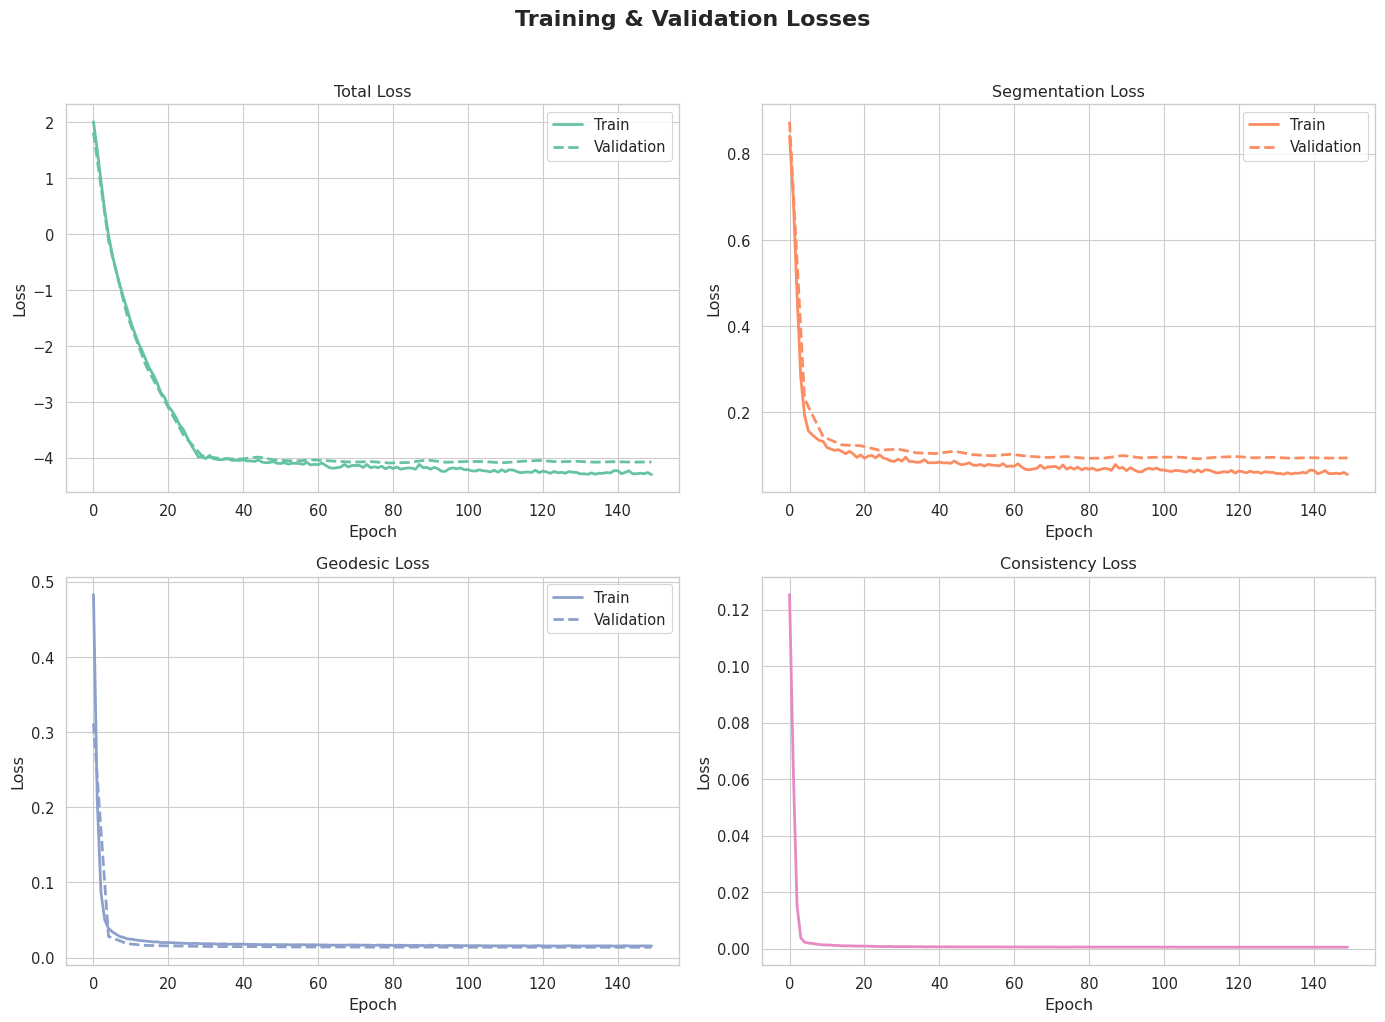

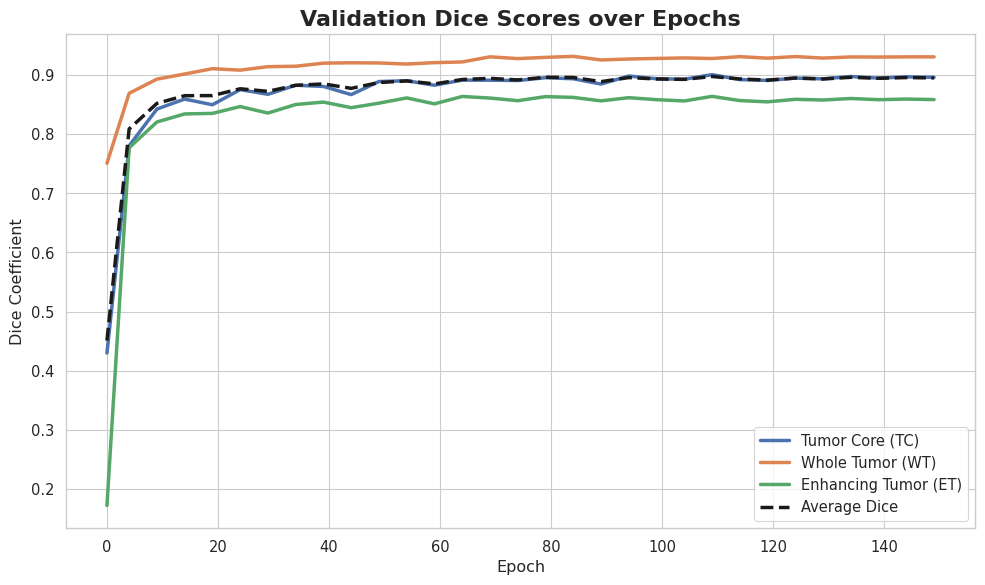

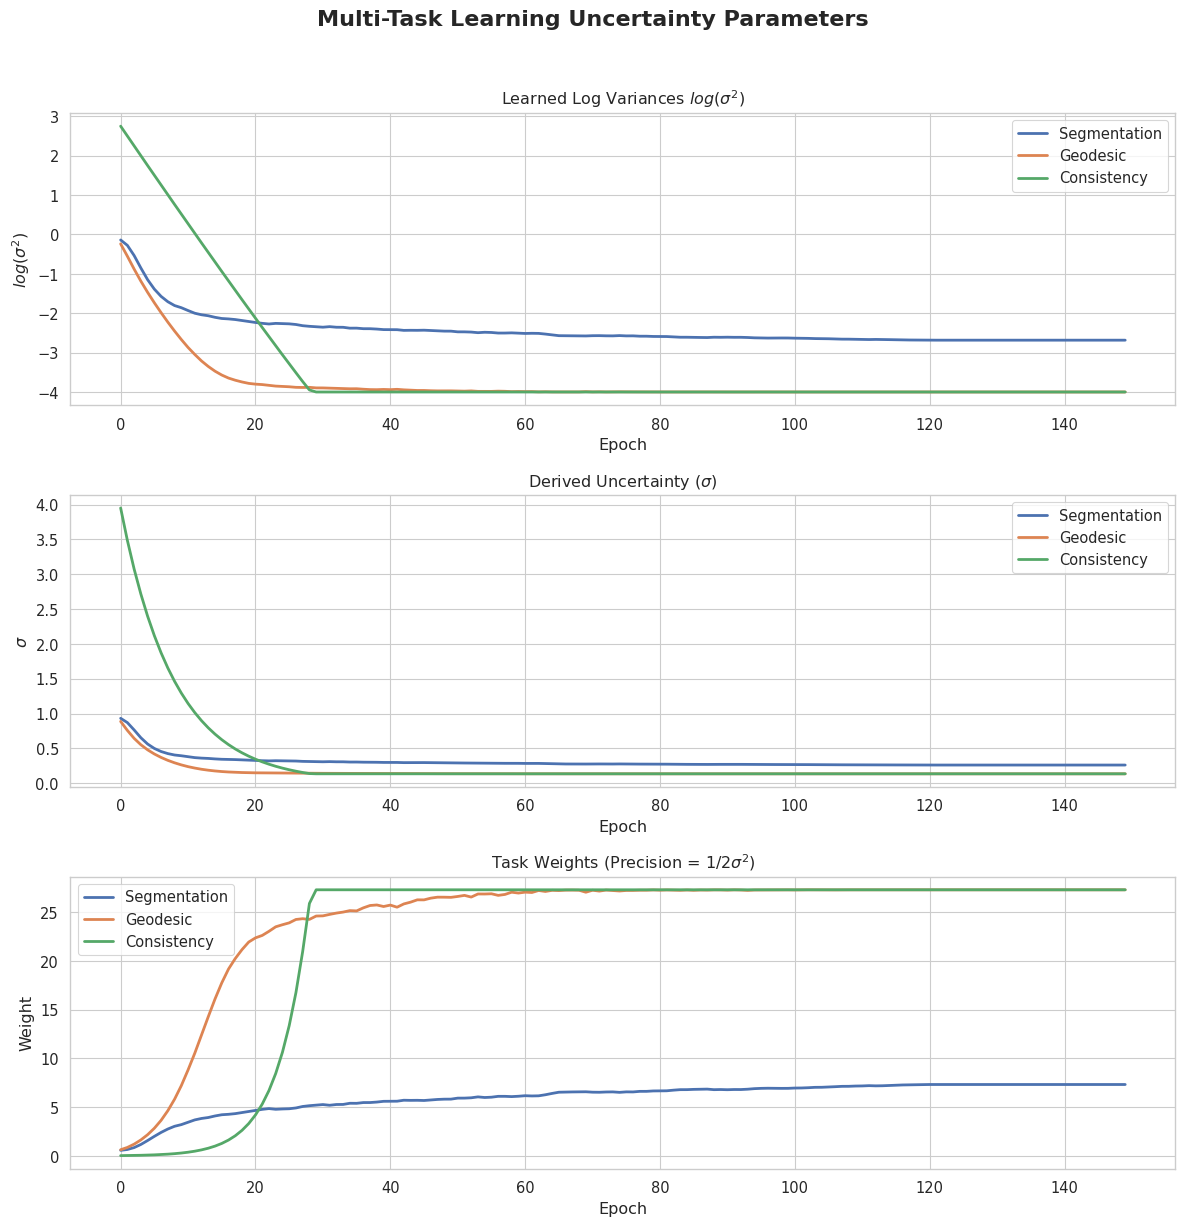

In [8]:
import torch
model_path = "/content/drive/MyDrive/brain_tumor_segmentation/Notebooks/runpod/Ablation studies/monai_data/experiments/proposed_method/model_last.pt"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = torch.load(model_path, map_location=device, weights_only=False)

print(model['epoch'])
print(model['best_acc'])

if isinstance(model, dict) and 'history' in model:
    history_dict = model['history']


plot_training_curves(history_dict, n =None)